<a href="https://colab.research.google.com/github/RojasG4mer/Fundamentos-de-Procesamiento-Digital-de-Imagenes/blob/main/Primer_examen_parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NOTA
En ningún código usar funciones de OpenCV más que la lectura y despliegue.

Para importar las imagenes desde un drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

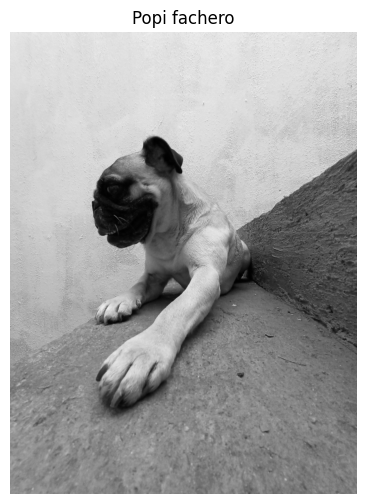

In [5]:

# Lectura, muestra y transformación a escala de grises
# Definir la ruta del archivo (ajusta el nombre del archivo)
path = '/content/drive/MyDrive/Procesamiento Digital del Imágenes/Popi_fachero.jpg'

# Leer la imagen
# Nota: OpenCV lee las imágenes en formato BGR por defecto
popi_fachero = cv2.imread(path)

if popi_fachero is None:
    print("Error: No se pudo cargar la imagen. Verifica que la ruta sea correcta.")
else:
    # 3. Convertir de BGR a RGB para mostrarla correctamente con Matplotlib
    popi_fachero_rgb = cv2.cvtColor(popi_fachero, cv2.COLOR_BGR2RGB)
    popi_fachero_grises = cv2.cvtColor(popi_fachero_rgb, cv2.COLOR_BGR2GRAY)
    # 4. Mostrar la imagen
    plt.figure(figsize=(7, 6))
    plt.imshow(popi_fachero_grises, cmap='gray')
    plt.title('Popi fachero')
    plt.axis('off')
    plt.show()
# print(popi_fachero_grises.max())


# Problema 1
Realizar lo siguiente:

*   Binarizar una imagen que deje en 0 el 30% de los pixéles menos brillante de la imagen y en 255 el resto.
*   Calcular el histograma de la imagen original.
*   Calcular el histograma de la imagen binarizada.



In [6]:
# Función para el histograma
def histo_casero(imagen):
  histograma = [0]*(imagen.max() + 1) # Creamos un arreglo de n+1 valores (contamos el cero)
  for i in imagen: #Nos metemos a la fila
    for pixel in i: #Nos metemos a cada pixel
      histograma[pixel] = histograma[pixel] + 1

  return np.array(histograma)

In [7]:
# Función para binarizar solo un porcentaje de los pixeles:
def umb_porcentaje(imagen, porcentaje): # Porcentaje en %, no en decimales
  histograma = histo_casero(imagen)
  Total_pixeles = np.sum(histograma)
  sum_acum = 0
  umbral = 0

  for i in histograma: # vemos el valor de pixeles en el histograma
    sum_acum = sum_acum + i # Sumamos cada valor hasta obtener la suma mayor
    if (sum_acum/Total_pixeles) >= (porcentaje/100): # Si el porcentaje es menor a la suma
      break
    umbral += 1
  print(umbral)

  binarizada = []
  fila = []
  for i in imagen: # nos metemos a la fila
    for pixel in i: #nos metemmos a cada pixel
      if pixel <= umbral: #Comparamos, si es menor la intensidad del pixel al umbral
        fila.append(0) # Se hace cero
      else:
        fila.append(254) #SIno se hace 255
    binarizada.append(fila)
    fila = []
  return np.array(binarizada)

126


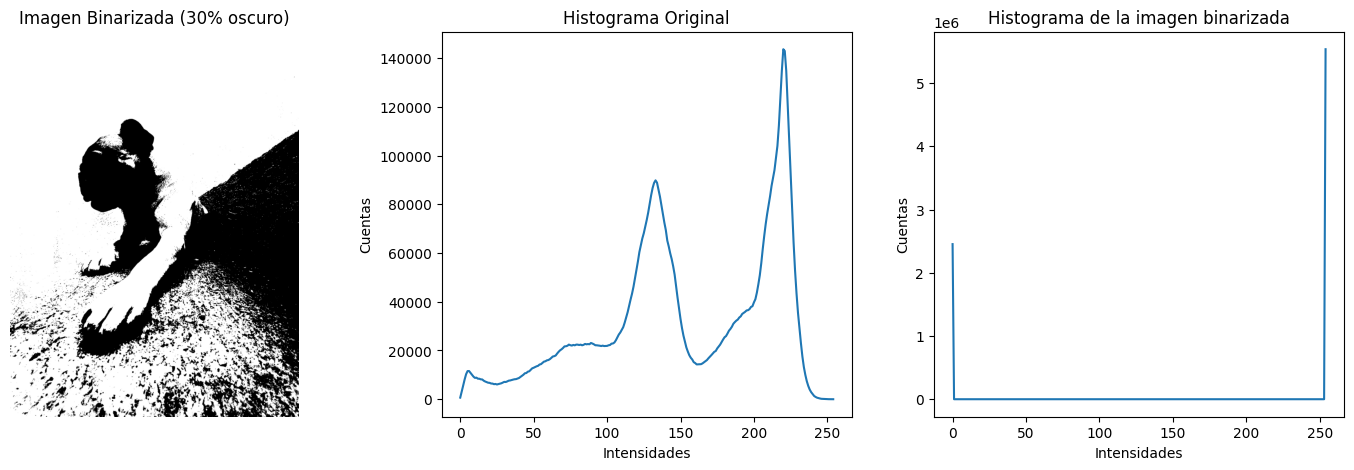

In [8]:
porcentaje = 30
histo_original = histo_casero(popi_fachero_grises)
popi_binarizado = umb_porcentaje(popi_fachero_grises, porcentaje)

# Ahora popi_binarizado no estará vacío, permitiendo calcular el histograma
histo_bina = histo_casero(popi_binarizado)

# Visualización de resultados
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].imshow(popi_binarizado, cmap='gray')
axs[0].set_title('Imagen Binarizada (30% oscuro)')
axs[0].axis('off')

axs[1].plot(histo_original)
axs[1].set_title('Histograma Original')
axs[1].set_xlabel('Intensidades')
axs[1].set_ylabel('Cuentas')

axs[2].plot(histo_bina)
axs[2].set_title('Histograma de la imagen binarizada')
axs[2].set_xlabel('Intensidades')
axs[2].set_ylabel('Cuentas')

plt.show()

In [9]:
filas_y, columnas_x = popi_fachero_grises.shape
print(filas_y, columnas_x)
print(len(popi_fachero_grises[:][0]))

3264 2448
2448


# Problema 2
Realice una función para trasladar una imagen $dx$ pixeles en $x$ y $dy$ pixeles en $y$. Eliminar la región de la imagen que salga de los límites.

In [10]:
def traslada(imagen, dx, dy):
  copia = imagen.copy()
  y, x = imagen.shape
  for j in range(y): # Empezamos en la posición dy de la imagen original
  #terminamos pasando al original, pero esto no es problema porque pondremos un condicional
    for i in range(x): # Empezamos en la posición dx de la imagen original
      if j >= y-dy or i >= x-dx: # Si la fila o colum es mayor a la diferencia entonces se vuelve negro
        copia[j][i] = 0
  return copia

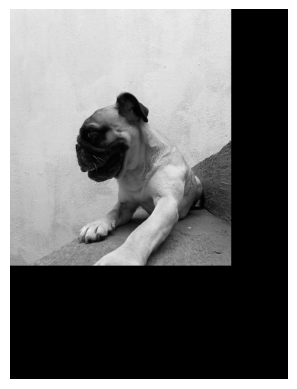

In [16]:
# Desplazando:
dx = 500
dy = 1000

im_desp = traslada(popi_fachero_grises, dx, dy)

plt.show((8, 6))
plt.imshow(im_desp, cmap = 'gray')
plt.axis('off')
plt.show()

# Problema 3
Hacer una función que extraiga la región de la imagen y genere una subimagen en una matriz.

In [12]:
def Extrae(Im, x, y, dx, dy):
  submatrix = [] #Recorte de la imagen
  fila = []
  temp_col_pix = []
  temp_fila = []
  for j in range(y, y+dy): #nos movemos desde el inicio del corte, hasta el corte
    for i in range(x, x+dx):
      temp_col_pix.append(i)
      fila.append(Im[j][i]) #agregamos el pixel de Im a cada fila nueva
    submatrix.append(fila) #agregamos cada fila a la imagen nueva
    fila = []
    temp_fila.append(temp_col_pix)
    # print(np.array(temp_fila).shape)
    temp_col_pix = []
  return np.array(submatrix)

(3264, 2448)


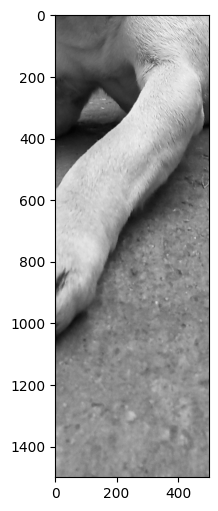

In [13]:
x = 1000
y = 1500
dx = 500
dy = 1500
print(popi_fachero_grises.shape)
recorte = Extrae(popi_fachero_grises, x, y, dx, dy)
plt.figure(figsize = (8,6))
plt.imshow(recorte, cmap = 'gray')
# plt.axis('off')
plt.show()


# Problema 4
Diseñe una función para transformar los niveles de gris de una imagen a la forma:

In [14]:
import numpy as np

def op_alpha(imagen, u1, u2, an_alpha):
    # 1. Aseguramos que el ángulo esté en radianes para todas las funciones trigonométricas
    alpha_rad = np.deg2rad(an_alpha)
    m = np.tan(alpha_rad) # La pendiente de la recta

    # 2. Calcular y0 (el punto de intersección en el eje Y de tu recta)
    x_dist = u2 - u1
    y_dist = x_dist * m
    y0 = 128 - (y_dist / 2) # Para que pase por 128 a la mitad del rango

    # 3. Crear una matriz de salida en formato float para evitar desbordamientos en los cálculos
    img_out = np.zeros_like(imagen, dtype=np.float32)

    # 4. Aplicar las condiciones (Vectorización)
    # Condición 1: Valores menores a u1 ya son 0 por defecto (np.zeros_like)

    # Condición 2: Valores entre u1 y u2 (aplicar la ecuación de la recta)
    mask_mid = (imagen >= u1) & (imagen < u2)
    img_out[mask_mid] = y0 + (imagen[mask_mid] - u1) * m

    # Condición 3: Valores mayores o iguales a u2 se saturan a 255
    mask_high = (imagen >= u2)
    img_out[mask_high] = 255

    # 5. Recortar los valores para que no se salgan del rango válido [0, 255]
    img_out = np.clip(img_out, 0, 255)

    # 6. Devolver la imagen en el formato estándar de imagen (enteros de 8 bits sin signo)
    return img_out.astype(np.uint8)

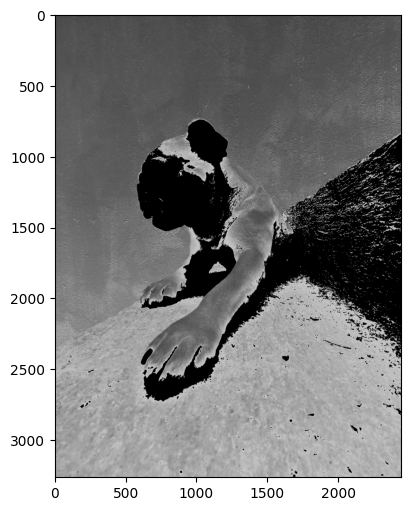

In [15]:
u1 = 100
u2 = 250
an_alpha = -45 # grados

ima_alpha = op_alpha(popi_fachero_grises, u1, u2, an_alpha)
plt.figure(figsize = (8,6))
plt.imshow(ima_alpha, cmap = 'gray')
# plt.axis('off')
plt.show()

# Problema 6
Suponga que usted tiene un sistema de visión robótica que está clasificando 3 objetos de diferente color y colocándolos mediante el brazo de un robot en 3 contenedores diferentes. ¿De qué forma resolvería el problema de clasificación utilizando los métodos y algoritmos de Visión Robótica vistos en clase?